# Ridge on the GPU via scikit-learn's Array API dispatch - what works

scikit-learn 1.8 can run a ridge fit on a GPU with no CUDA-specific estimator: hand it a
`torch` CUDA tensor and switch on *Array API dispatch*
([doc](https://scikit-learn.org/stable/modules/array_api.html)).

This notebook maps out **which combinations actually run**, on deliberately small matrices
so the whole thing takes seconds:

* two shapes - **tall** (`n_samples > n_features`) and **wide** (`n_samples <= n_features`,
  the rocket-feature regime);
* four estimators - `RidgeClassifier` with its **default solver** and with `solver="svd"`
  and `solver="cholesky"`, plus `RidgeClassifierCV` with its **default LOO-GCV**;
* CPU and CUDA, float32 and float64.

Nothing is patched. Failures are recorded in the table as the exception the stock library
raises. The last cell says how large you can go before the GPU runs out of memory.

**Timings here are not meaningful** - the matrices are tiny, so the numbers are dominated
by per-call overhead (and by whatever else is running on the machine). Scale the shapes up
once the support matrix looks right.

In [1]:
import os
import sys

if "scipy" in sys.modules or "sklearn" in sys.modules:
    raise RuntimeError(
        "scipy/sklearn already imported - restart the kernel and run this cell first, "
        "SCIPY_ARRAY_API must be set before the import."
    )
os.environ["SCIPY_ARRAY_API"] = "1"

import time
import warnings

import numpy as np
import polars as pl
import sklearn
import torch
from sklearn import config_context
from sklearn.linear_model import RidgeClassifier, RidgeClassifierCV
from sklearn.metrics import accuracy_score

from scipy.linalg import LinAlgWarning
from threadpoolctl import threadpool_limits

# "solver='auto' under dispatch resolves to svd" - expected, and one of the things measured
warnings.filterwarnings("ignore", message=".*solver='auto'.*")
# the cholesky solver on a wide matrix is legitimately ill-conditioned; not what we measure
warnings.filterwarnings("ignore", category=LinAlgWarning)

# Pin the CPU baseline. Letting BLAS take all 32 cores looks fair but is not: when the box
# is busy the threads thrash and a 250x2500 SVD that costs 0.3 s at 1-16 threads takes 12 s
# at 32. 16 is what the benchmark jobs (run_benchmark2.py) actually get.
CPU_THREADS = 16

print(f"sklearn {sklearn.__version__}, torch {torch.__version__}, "
      f"{os.cpu_count()} cores, CPU baseline pinned to {CPU_THREADS} BLAS threads, "
      f"load average {os.getloadavg()[0]:.1f}")
props = torch.cuda.get_device_properties(0)
free, total = torch.cuda.mem_get_info()
print(f"gpu     {props.name} (sm_{props.major}{props.minor}), "
      f"{free / 2**30:.2f} GiB free / {total / 2**30:.2f} GiB")

sklearn 1.8.0, torch 2.13.0+cu132, 32 cores, CPU baseline pinned to 16 BLAS threads, load average 0.1
gpu     NVIDIA RTX PRO 4000 Blackwell (sm_120), 23.23 GiB free / 23.46 GiB


## The rules

* the namespace and device of `X` decide where the fit runs - `y` may stay a numpy array;
* `coef_` and whatever `predict` returns come back as CUDA tensors, so `predict` has to be
  called inside the dispatch context too;
* `Ridge`/`RidgeClassifier` are supported **only with `solver="svd"`**. `solver="auto"`
  silently resolves to `svd` under dispatch (with a warning that numpy would have picked
  something else); any other explicit solver raises;
* `RidgeCV`/`RidgeClassifierCV` are listed as supported, with a float64 caveat - their
  GCV path computes in float64 on CUDA whatever dtype you hand it.

In [2]:
SHAPES = {           # (n_samples, n_features) - keep these small, they are a support check
    "tall 600x300": (600, 300),
    "wide 300x600": (300, 600),
}
N_CLASSES = 4
ALPHAS = np.logspace(-3, 3, 10)

MODELS = {
    "RidgeClassifier()": lambda: RidgeClassifier(alpha=1.0),
    "RidgeClassifier(svd)": lambda: RidgeClassifier(alpha=1.0, solver="svd"),
    "RidgeClassifier(cholesky)": lambda: RidgeClassifier(alpha=1.0, solver="cholesky"),
    "RidgeClassifierCV()": lambda: RidgeClassifierCV(alphas=ALPHAS),
}


def make_data(n_samples, n_features, seed=0):
    rng = np.random.default_rng(seed)
    X = rng.standard_normal((n_samples, n_features), dtype=np.float32)
    y = rng.integers(0, N_CLASSES, n_samples)
    X[:, :20] += 1.5 * y[:, None]  # make it learnable
    return X, y


DATA = {name: make_data(*shape) for name, shape in SHAPES.items()}
print({k: v[0].shape for k, v in DATA.items()})

{'tall 600x300': (600, 300), 'wide 300x600': (300, 600)}


In [3]:
cpu_reference = {}  # (model, shape) -> predictions of the CPU float64 fit


def run(model_name, make_model, shape_name, device, dtype):
    """Fit and predict one combination; record the exception instead of raising."""
    X, y = DATA[shape_name]
    row = {"shape": shape_name, "model": model_name, "device": device, "dtype": dtype}
    try:
        if device == "cpu":
            Xd = X.astype(dtype)
            with threadpool_limits(limits=CPU_THREADS):
                t0 = time.perf_counter()
                model = make_model().fit(Xd, y)
                row["fit_s"] = time.perf_counter() - t0
                pred = model.predict(Xd)
        else:
            torch.cuda.empty_cache()
            torch.cuda.reset_peak_memory_stats()
            Xd = torch.asarray(X, device="cuda", dtype=getattr(torch, dtype))
            with config_context(array_api_dispatch=True):
                t0 = time.perf_counter()
                model = make_model().fit(Xd, y)
                torch.cuda.synchronize()
                row["fit_s"] = time.perf_counter() - t0
                pred = model.predict(Xd).cpu().numpy()
            row["peak_mib"] = torch.cuda.max_memory_allocated() / 2**20
            del Xd
            torch.cuda.empty_cache()
    except Exception as exc:  # noqa: BLE001 - the point is to record what fails
        row["status"] = type(exc).__name__
        row["detail"] = str(exc).splitlines()[0]
        return row

    row["status"] = "ok"
    row["accuracy"] = accuracy_score(y, pred)
    row["alpha"] = float(getattr(model, "alpha_", model.get_params().get("alpha")))
    key = (model_name, shape_name)
    if device == "cpu" and dtype == "float64":
        cpu_reference[key] = pred
    elif key in cpu_reference:
        row["agrees_with_cpu"] = float(np.mean(pred == cpu_reference[key]))
    return row


# warm-up so the first CUDA call does not pay for context creation
with config_context(array_api_dispatch=True):
    RidgeClassifier(alpha=1.0, solver="svd").fit(
        torch.asarray(DATA["tall 600x300"][0][:50, :20], device="cuda"),
        DATA["tall 600x300"][1][:50],
    )
torch.cuda.empty_cache()

rows = [
    run(model_name, make_model, shape_name, device, dtype)
    for shape_name in SHAPES
    for model_name, make_model in MODELS.items()
    for device in ("cpu", "cuda")
    for dtype in ("float64", "float32")  # float64 first: it is the CPU reference
]

results = pl.DataFrame(rows)
pl.Config(fmt_str_lengths=30, tbl_rows=50, tbl_width_chars=170)
results.select("shape", "model", "device", "dtype", "status", "fit_s", "accuracy",
               "alpha", "agrees_with_cpu", "peak_mib").with_columns(
    pl.col(pl.Float64).round(3)
)

shape,model,device,dtype,status,fit_s,accuracy,alpha,agrees_with_cpu,peak_mib
str,str,str,str,str,f64,f64,f64,f64,f64
"""tall 600x300""","""RidgeClassifier()""","""cpu""","""float64""","""ok""",0.009,0.938,1.0,null,null
"""tall 600x300""","""RidgeClassifier()""","""cpu""","""float32""","""ok""",0.004,0.938,1.0,1.0,null
"""tall 600x300""","""RidgeClassifier()""","""cuda""","""float64""","""ok""",0.229,0.938,1.0,1.0,44.54
"""tall 600x300""","""RidgeClassifier()""","""cuda""","""float32""","""ok""",0.014,0.938,1.0,1.0,115.829
"""tall 600x300""","""RidgeClassifier(svd)""","""cpu""","""float64""","""ok""",0.035,0.938,1.0,null,null
"""tall 600x300""","""RidgeClassifier(svd)""","""cpu""","""float32""","""ok""",0.033,0.938,1.0,1.0,null
"""tall 600x300""","""RidgeClassifier(svd)""","""cuda""","""float64""","""ok""",0.127,0.938,1.0,1.0,44.54
"""tall 600x300""","""RidgeClassifier(svd)""","""cuda""","""float32""","""ok""",0.013,0.938,1.0,1.0,115.829
"""tall 600x300""","""RidgeClassifier(cholesky)""","""cpu""","""float64""","""ok""",0.005,0.938,1.0,null,null


## Support matrix

`ok` means the fit and the `predict` both ran; anything else is the exception class raised
by the stock 1.8.0 library.

In [4]:
support = results.pivot(
    on=["device", "dtype"], index=["model", "shape"], values="status",
    aggregate_function="first",
)
support.columns = [c.replace('{"', "").replace('"}', "").replace('","', "/")
                   for c in support.columns]
print(support)

print("\nwhat the failures say:")
for row in results.filter(pl.col("status") != "ok").select(
    "model", "shape", "device", "dtype", "detail"
).unique(subset=["model", "shape", "detail"], maintain_order=True).iter_rows(named=True):
    print(f"  {row['model']} / {row['shape']} / {row['device']}: {row['detail'][:110]}")

shape: (8, 6)
┌───────────────────────────┬──────────────┬─────────────┬─────────────┬──────────────┬──────────────┐
│ model                     ┆ shape        ┆ cpu/float64 ┆ cpu/float32 ┆ cuda/float64 ┆ cuda/float32 │
│ ---                       ┆ ---          ┆ ---         ┆ ---         ┆ ---          ┆ ---          │
│ str                       ┆ str          ┆ str         ┆ str         ┆ str          ┆ str          │
╞═══════════════════════════╪══════════════╪═════════════╪═════════════╪══════════════╪══════════════╡
│ RidgeClassifier()         ┆ tall 600x300 ┆ ok          ┆ ok          ┆ ok           ┆ ok           │
│ RidgeClassifier(svd)      ┆ tall 600x300 ┆ ok          ┆ ok          ┆ ok           ┆ ok           │
│ RidgeClassifier(cholesky) ┆ tall 600x300 ┆ ok          ┆ ok          ┆ ValueError   ┆ ValueError   │
│ RidgeClassifierCV()       ┆ tall 600x300 ┆ ok          ┆ ok          ┆ ok           ┆ ok           │
│ RidgeClassifier()         ┆ wide 300x600 ┆ ok          ┆ 

## What this says

* **`RidgeClassifier` runs on the GPU in every shape and dtype** - with `solver="svd"`, and
  with the default `solver="auto"`, which resolves to `svd` under dispatch. An explicit
  non-svd solver (`cholesky`, and likewise `lsqr`/`sag`/`saga`) is refused with
  *"Array API dispatch ... only supports solver 'svd'"*. On the CPU those solvers are fine
  and `auto` picks `cholesky`, so the default estimator quietly changes algorithm when you
  move it to the GPU.
* **`RidgeClassifierCV()` (default LOO-GCV) runs on the GPU only when `n_samples >
  n_features`.** That is why it worked in earlier tests and fails on rocket-shaped data:
  `_check_gcv_mode` sends tall matrices through `_svd_decompose_design_matrix`, which passes
  `device=`, and wide ones through the Gram branch, whose `_compute_gram` builds `X_mean`
  without `device=`. The wide case then dies in `X_offset += X_mean * X_scale`. It is a
  one-line bug in scikit-learn 1.8.0, not something about our data.
* **So there is no cross-validated ridge on the GPU for wide data in 1.8.0.** GCV is the
  only alpha search `RidgeClassifierCV` has, and on wide matrices it is the broken branch.
  Either fix `_compute_gram`, or pick alpha some other way and fit `RidgeClassifier` with
  it on the GPU.
* **Predictions match the CPU** wherever both sides run (`agrees_with_cpu` = 1.0), in both
  dtypes.

## Scaling up

Peak GPU memory for these fits is ~7 copies of `X` (the tensors plus the cuSOLVER
workspace), and the CV estimators compute in float64 on CUDA regardless of the dtype you
pass, so budget on float64. The cell below prints the largest wide matrix that fits in the
memory free right now. The timing sweep below re-checks this before every size, so it
stops growing instead of running out of memory.

In [5]:
PEAK_COPIES = 7.2   # measured: 893 MiB for 1800x18000 float32, 1795 MiB for float64
HEADROOM = 1.15     # the card is shared, leave room
RATIO = 10          # n_features / n_samples


def gpu_peak_bytes(n_samples, n_features, itemsize=8):
    """Expected peak CUDA memory for one fit (float64 is the binding case)."""
    return PEAK_COPIES * n_samples * n_features * itemsize


def fits_on_gpu(n_samples, n_features):
    """Check the expected peak against the memory free right now."""
    return HEADROOM * gpu_peak_bytes(n_samples, n_features) < torch.cuda.mem_get_info()[0]


free_bytes = torch.cuda.mem_get_info()[0]
n_max = int((free_bytes / (HEADROOM * PEAK_COPIES * 8 * RATIO)) ** 0.5 // 100 * 100)

print(f"{free_bytes / 2**30:.2f} GiB free now")
print(f"largest 1:{RATIO} shape that fits: {n_max} x {RATIO * n_max} "
      f"({n_max * RATIO * n_max * 8 / 2**20:.0f} MiB as float64, "
      f"expected peak ~{gpu_peak_bytes(n_max, RATIO * n_max) / 2**20:.0f} MiB)")
print("\nmeasured earlier on an idle card, 1800 x 18000:")
print("  RidgeClassifier(svd) GPU float32   2.8 s   peak  893 MiB")
print("  RidgeClassifier(svd) GPU float64  21.1 s   peak 1795 MiB")

22.83 GiB free now
largest 1:10 shape that fits: 6000 x 60000 (2747 MiB as float64, expected peak ~19775 MiB)

measured earlier on an idle card, 1800 x 18000:
  RidgeClassifier(svd) GPU float32   2.8 s   peak  893 MiB
  RidgeClassifier(svd) GPU float64  21.1 s   peak 1795 MiB


## Is the GPU actually worth it?

The support matrix says *what runs*; this says *whether to bother*. Same data on both
sides, timed at growing wide shapes until either the memory budget above or a 20 s per-fit
time budget stops the sweep. Fast fits are run three times and the fastest is reported,
since contention on a shared box only ever adds time. Two estimators are timed:

* `RidgeClassifier()` - the default, i.e. **cholesky on the CPU vs svd on the GPU**, which
  is what you would actually run on each device;
* `RidgeClassifier(svd)` - **the same algorithm on both sides**, which separates "the GPU is
  faster" from "the GPU was handed a different solver".

The CPU column is float64 (what sklearn computes in anyway) on `CPU_THREADS` threads; the
GPU is timed in both dtypes, because the fp64 rate is the whole question on a workstation
card.

In [6]:
TIMED_MODELS = {
    "RidgeClassifier()": MODELS["RidgeClassifier()"],
    "RidgeClassifier(svd)": MODELS["RidgeClassifier(svd)"],
}
SIZES = [(250, 2500), (500, 5000), (1000, 10000), (1500, 15000),
         (2000, 20000), (3000, 30000), (9_000, 50_000)]
TIME_BUDGET_S = 20
REPEATS = 3  # report the fastest run: this box is shared, and contention only adds time


def _one_fit(make_model, X, y, device, dtype):
    if device == "cpu":
        Xd = X.astype(dtype)
        with threadpool_limits(limits=CPU_THREADS):
            t0 = time.perf_counter()
            model = make_model().fit(Xd, y)
            return time.perf_counter() - t0, model.predict(Xd)
    torch.cuda.empty_cache()
    Xd = torch.asarray(X, device="cuda", dtype=getattr(torch, dtype))
    with config_context(array_api_dispatch=True):
        t0 = time.perf_counter()
        model = make_model().fit(Xd, y)
        torch.cuda.synchronize()
        secs = time.perf_counter() - t0
        pred = model.predict(Xd).cpu().numpy()
    del Xd
    torch.cuda.empty_cache()
    return secs, pred


REPEAT_IF_UNDER_S = 5  # a fit this slow is repeated once at most: noise matters less


def fit_time(make_model, X, y, device, dtype):
    """Return (fastest seconds over up to REPEATS runs, predictions)."""
    best = _one_fit(make_model, X, y, device, dtype)
    for _ in range(REPEATS - 1):
        if best[0] > REPEAT_IF_UNDER_S:
            break
        best = min(best, _one_fit(make_model, X, y, device, dtype), key=lambda r: r[0])
    return best


timing_rows = []
for model_name, make_model in TIMED_MODELS.items():
    for n_samples, n_features in SIZES:
        if not fits_on_gpu(n_samples, n_features):
            print(f"{model_name}: stopping at {n_samples}x{n_features}, over the GPU "
                  f"memory budget ({torch.cuda.mem_get_info()[0] / 2**30:.2f} GiB free)")
            break
        X, y = make_data(n_samples, n_features, seed=n_samples)
        try:
            cpu_s, cpu_pred = fit_time(make_model, X, y, "cpu", "float64")
            cpu32_s, _ = fit_time(make_model, X, y, "cpu", "float32")
            gpu32_s, gpu32_pred = fit_time(make_model, X, y, "cuda", "float32")
            gpu64_s, _ = fit_time(make_model, X, y, "cuda", "float64")
        except torch.OutOfMemoryError:
            print(f"{model_name}: CUDA OOM at {n_samples}x{n_features} "
                  f"(something else took the card); stopping")
            torch.cuda.empty_cache()
            del X
            break
        timing_rows.append({
            "model": model_name,
            "shape": f"{n_samples}x{n_features}",
            "cpu_s": cpu_s,
            "cpu32_s": cpu32_s,
            "gpu32_s": gpu32_s,
            "gpu64_s": gpu64_s,
            "speedup_f32": cpu_s / gpu32_s,
            "speedup_f64": cpu_s / gpu64_s,
            "agrees_with_cpu": float(np.mean(cpu_pred == gpu32_pred)),
        })
        print(f"{model_name:24s} {n_samples:5d}x{n_features:<6d} "
              f"cpu f64 {cpu_s:6.2f}s  cpu f32 {cpu32_s:6.2f}s | "
              f"gpu f32 {gpu32_s:6.2f}s ({cpu_s / gpu32_s:5.1f}x) | "
              f"gpu f64 {gpu64_s:6.2f}s ({cpu_s / gpu64_s:5.1f}x)")
        del X
        if max(cpu_s, gpu64_s) > TIME_BUDGET_S:
            print(f"{model_name}: stopping, over the {TIME_BUDGET_S}s time budget")
            break

timings = pl.DataFrame(timing_rows)
print()
for model_name in TIMED_MODELS:
    sub = timings.filter(pl.col("model") == model_name)
    n = len(sub)
    wins32 = int((sub["speedup_f32"] > 1).sum())
    wins64 = int((sub["speedup_f64"] > 1).sum())
    print(f"{model_name}: GPU float32 faster at {wins32}/{n} sizes "
          f"({sub['speedup_f32'].min():.1f}-{sub['speedup_f32'].max():.1f}x), "
          f"float64 at {wins64}/{n} "
          f"({sub['speedup_f64'].min():.1f}-{sub['speedup_f64'].max():.1f}x)")
print(f"(best of up to {REPEATS} runs, CPU on {CPU_THREADS} threads; "
      f"load average {os.getloadavg()[0]:.1f})")

timings.with_columns(pl.col(pl.Float64).round(3))

RidgeClassifier()          250x2500   cpu f64   0.01s  cpu f32   0.00s | gpu f32   0.01s (  0.7x) | gpu f64   0.09s (  0.1x)
RidgeClassifier()          500x5000   cpu f64   0.03s  cpu f32   0.02s | gpu f32   0.02s (  1.4x) | gpu f64   0.27s (  0.1x)
RidgeClassifier()         1000x10000  cpu f64   0.13s  cpu f32   0.08s | gpu f32   0.06s (  2.1x) | gpu f64   0.93s (  0.1x)
RidgeClassifier()         1500x15000  cpu f64   0.29s  cpu f32   0.16s | gpu f32   0.15s (  2.0x) | gpu f64   2.38s (  0.1x)
RidgeClassifier()         2000x20000  cpu f64   0.56s  cpu f32   0.29s | gpu f32   0.31s (  1.8x) | gpu f64   4.24s (  0.1x)
RidgeClassifier()         3000x30000  cpu f64   1.46s  cpu f32   0.76s | gpu f32   1.34s (  1.1x) | gpu f64  14.78s (  0.1x)
RidgeClassifier(): stopping at 9000x50000, over the GPU memory budget (22.82 GiB free)
RidgeClassifier(svd)       250x2500   cpu f64   0.11s  cpu f32   0.11s | gpu f32   0.01s ( 10.9x) | gpu f64   0.09s (  1.3x)
RidgeClassifier(svd)       500x5000   

model,shape,cpu_s,cpu32_s,gpu32_s,gpu64_s,speedup_f32,speedup_f64,agrees_with_cpu
str,str,f64,f64,f64,f64,f64,f64,f64
"""RidgeClassifier()""","""250x2500""",0.008,0.005,0.011,0.09,0.74,0.089,1.0
"""RidgeClassifier()""","""500x5000""",0.033,0.017,0.023,0.271,1.394,0.121,1.0
"""RidgeClassifier()""","""1000x10000""",0.135,0.078,0.064,0.93,2.107,0.145,1.0
"""RidgeClassifier()""","""1500x15000""",0.293,0.158,0.149,2.377,1.96,0.123,1.0
"""RidgeClassifier()""","""2000x20000""",0.564,0.295,0.306,4.237,1.844,0.133,1.0
"""RidgeClassifier()""","""3000x30000""",1.463,0.763,1.338,14.782,1.093,0.099,1.0
"""RidgeClassifier(svd)""","""250x2500""",0.115,0.113,0.011,0.085,10.861,1.344,1.0
"""RidgeClassifier(svd)""","""500x5000""",0.417,0.415,0.023,0.256,18.465,1.631,1.0
"""RidgeClassifier(svd)""","""1000x10000""",1.758,1.756,0.061,0.877,28.784,2.005,1.0


## Fit time, every combination

Raw seconds, not ratios. Colour is where it ran and which decomposition it used; solid is
float32, dashed float64. Both axes are logarithmic, so a constant vertical gap is a
constant factor.

Two pairs of lines sit on top of each other, and both are results rather than plotting
mistakes:

* **CPU svd float32 and float64 coincide** - `solver="svd"` gets nothing from float32 on
  the CPU (8.16 s against 8.19 s at 2000x20000). CPU cholesky does: it roughly halves
  (0.79 s against 1.53 s at 3000x30000).
* **GPU svd float32 and CPU cholesky float32 nearly coincide** - the forced svd on the GPU
  ends up costing about what the CPU's much cheaper decomposition costs. That is the whole
  argument about whether to use the GPU here, visible as one gap.

The GPU line appears once: Array API dispatch forces `solver="svd"`, so the GPU timings
under `RidgeClassifier()` and `RidgeClassifier(svd)` are the same computation.


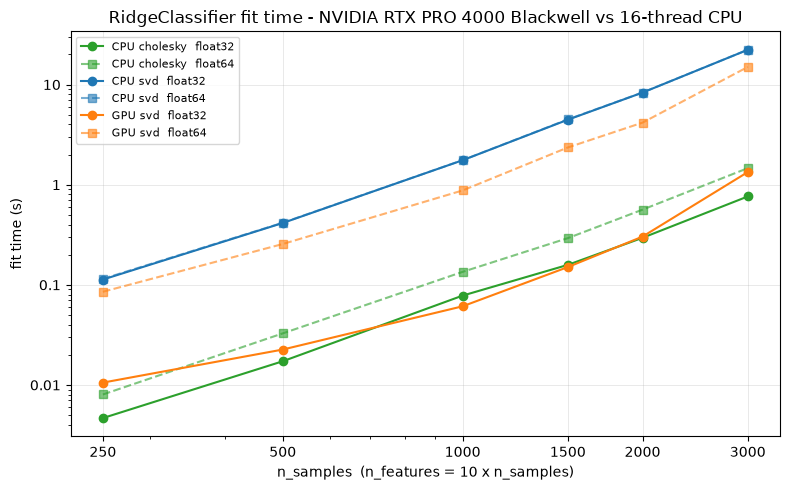

In [7]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

SERIES = [                     # label, model to read the column from, f32 col, f64 col, colour
    ("CPU cholesky", "RidgeClassifier()",    "cpu32_s", "cpu_s",   "tab:green"),
    ("CPU svd",      "RidgeClassifier(svd)", "cpu32_s", "cpu_s",   "tab:blue"),
    ("GPU svd",      "RidgeClassifier(svd)", "gpu32_s", "gpu64_s", "tab:orange"),
]

fig, ax = plt.subplots(figsize=(8, 5))
for label, model_name, col32, col64, colour in SERIES:
    sub = timings.filter(pl.col("model") == model_name)
    n_samples = [int(s.split("x")[0]) for s in sub["shape"]]
    ax.plot(n_samples, sub[col32], "o-", color=colour, label=f"{label}  float32")
    ax.plot(n_samples, sub[col64], "s--", color=colour, alpha=0.6,
            label=f"{label}  float64")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xticks([int(s.split("x")[0]) for s in timings["shape"].unique(maintain_order=True)])
for axis in (ax.xaxis, ax.yaxis):
    axis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
    axis.set_minor_formatter(FuncFormatter(lambda v, _: ""))
ax.set_xlabel(f"n_samples  (n_features = {RATIO} x n_samples)")
ax.set_ylabel("fit time (s)")
ax.set_title(f"RidgeClassifier fit time - {torch.cuda.get_device_properties(0).name} "
             f"vs {CPU_THREADS}-thread CPU")
ax.legend(fontsize=8, loc="upper left")
ax.grid(True, which="major", lw=0.4, alpha=0.5)
fig.tight_layout()
plt.show()